In [1]:
%load_ext autoreload
%autoreload 2
from loguru import logger
import sys
import json

In [2]:
import matplotlib.pyplot as plt
import scienceplots
import matplotlib
plt.style.use(['science'])


In [3]:
result_folder = "results"
task_datasets = {
    "activity": "paged",
    "programs": "clevr",
    "taxonomy": "wordnet"
}

## Taxonomy Construction

In [68]:
task = "activity"
dataset = task_datasets[task]
dataset_title = "PAGED"

In [69]:
result_file_path = f"{result_folder}/{task}/candidates_{dataset}.json"
with open(result_file_path) as f:
    results = json.load(f)

In [70]:
llms = list(sorted(results[0]["mv"].keys()))
approaches = ["mv", "abscon", "max", "median", "greedy"]
approach_names = ["MV", "AbsCon", "Best", "Median", "Direct"]
lines = ["-", "-", "--", "--", "-"]
markers = ['*', '.', '^', 'v', '']

colors = [[33, 25, 24], [195, 56, 40], [71, 133, 90] , [71, 133, 90],  [231, 189, 57]]
colors = [[c / 255 for c in color] for color in colors]

In [71]:
approaches

['mv', 'abscon', 'max', 'median', 'greedy']

[0.950920245398773, 0.9693251533742331, 0.9631901840490797, 0.9723926380368099, 0.9662576687116564, 0.9662576687116564, 0.9693251533742331, 0.9662576687116564, 0.9693251533742331, 0.9601226993865031, 0.9601226993865031, 0.9570552147239264, 0.9631901840490797, 0.9662576687116564, 0.9631901840490797, 0.9693251533742331, 0.9662576687116564, 0.9631901840490797, 0.9662576687116564, 0.9723926380368099]
[0.9294478527607362, 0.9631901840490797, 0.9815950920245399, 0.99079754601227, 0.99079754601227, 0.99079754601227, 0.9938650306748467, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233]
[0.9294478527607362, 0.9279141104294478, 0.9478527607361963, 0.950920245398773, 0.9601226993865031, 0.9570552147239264, 0.9570552147239264, 0.9601226993865031, 0.9631901840490797, 0.9631901840490797, 0.960

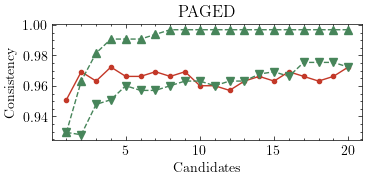

[0.9294478527607362, 0.9662576687116564, 0.9754601226993865, 0.9815950920245399, 0.9846625766871165, 0.9846625766871165, 0.9877300613496932, 0.9846625766871165, 0.9846625766871165, 0.9846625766871165, 0.9846625766871165, 0.9754601226993865, 0.9785276073619632, 0.9785276073619632, 0.9785276073619632, 0.9846625766871165, 0.9846625766871165, 0.9846625766871165, 0.9815950920245399, 0.9815950920245399]
[0.911042944785276, 0.9785276073619632, 0.99079754601227, 0.9938650306748467, 0.9969325153374233, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.911042944785276, 0.9141104294478528, 0.9570552147239264, 0.9616564417177914, 0.9693251533742331, 0.9693251533742331, 0.9723926380368099, 0.9723926380368099, 0.9754601226993865, 0.9723926380368099, 0.9662576687116564, 0.9693251533742331, 0.9693251533742331, 0.9708588957055214, 0.9754601226993865, 0.9739263803680982, 0.9723926380368099, 0.9754601226993865, 0.9815950920245399, 0.9785276073619632]


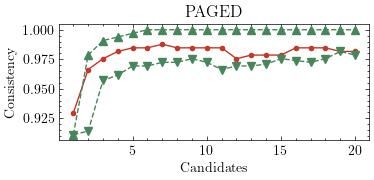

[0.9723926380368099, 0.9693251533742331, 0.9846625766871165, 0.9785276073619632, 0.9846625766871165, 0.9877300613496932, 0.9846625766871165, 0.9846625766871165, 0.9846625766871165, 0.99079754601227, 0.9877300613496932, 0.9877300613496932, 0.9877300613496932, 0.9846625766871165, 0.9877300613496932, 0.9846625766871165, 0.99079754601227, 0.9877300613496932, 0.9877300613496932, 0.9877300613496932]
[0.9601226993865031, 0.9846625766871165, 0.9877300613496932, 0.99079754601227, 0.99079754601227, 0.99079754601227, 0.9938650306748467, 0.9938650306748467, 0.9938650306748467, 0.9938650306748467, 0.9938650306748467, 0.9938650306748467, 0.9938650306748467, 0.9938650306748467, 0.9938650306748467, 0.9938650306748467, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233, 0.9969325153374233]
[0.9601226993865031, 0.9570552147239264, 0.9815950920245399, 0.9769938650306749, 0.9815950920245399, 0.9800613496932515, 0.9815950920245399, 0.9800613496932515, 0.9846625766871165, 0.9846625766871165, 0.98466

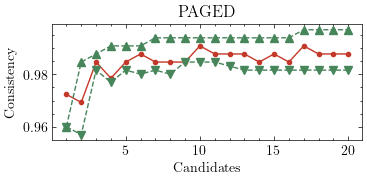

In [72]:
metric = "consistency"
x = range(1, 21)
f1_values = []
for llm in llms:
    plt.figure(figsize=(4,1.5))
    for j, approach in enumerate(approaches):
        if approach in ["greedy", "mv"]:
            continue
        values = [data[approach][llm][metric] for data in results]
        print(values)
        if approach in ["mv", "abscon"]:
            f1_values.extend(values)
        plt.plot(x, values, color=colors[j], linestyle=lines[j], label=approach_names[j], marker=markers[j])
    # plt.legend(shadow=True, ncol=2)
    plt.title(dataset_title)
    plt.ylabel("Consistency")
    plt.xlabel("Candidates")
    plt.savefig(f"{dataset}_{llm}.pdf", dpi=300)
    plt.show()        

In [50]:
task = "programs"
dataset = task_datasets[task]

In [51]:
result_file_path = f"{result_folder}/{task}/candidates_{dataset}.json"
with open(result_file_path) as f:
    results = json.load(f)

In [52]:
llms = list(sorted(results[0]["mv"].keys()))
approaches = ["escf", "abscon", "best", "esc", "greedy"]
approach_names = ["Best baseline", "AbsCon", "Best", "Median", "Direct"]
lines = ["-", "-", "--", "--", "-"]
markers = ['*', '.', '^', 'v', '']

colors = [[33, 25, 24], [195, 56, 40], [71, 133, 90] , [71, 133, 90],  [231, 189, 57]]
colors = [[c / 255 for c in color] for color in colors]

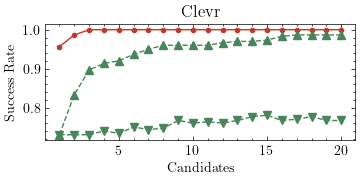

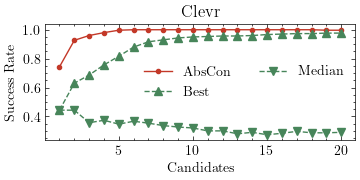

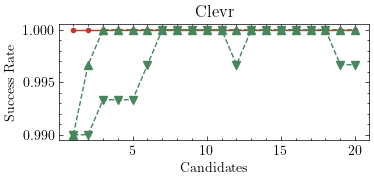

In [62]:
metric = "success_rate"
x = range(1, 21)
f1_values = []
for llm in llms:
    plt.figure(figsize=(4,1.5))
    for j, approach in enumerate(approaches):
        if approach in ["greedy", "escf"]:
            continue
        values = [data[approach][llm][metric] for data in results]
        if approach in ["escf", "abscon"]:
            f1_values.extend(values)
        plt.plot(x, values, color=colors[j], linestyle=lines[j], label=approach_names[j], marker=markers[j])
    if llm == "Meta-Llama-3.1-8B-Instruct":
        plt.legend(shadow=True, ncol=2)
    plt.title("Clevr")
    plt.ylabel("Success Rate")
    plt.xlabel("Candidates")
    plt.savefig(f"{dataset}_{llm}.pdf", dpi=300)
    plt.show()        